In [2]:
from pandas import read_csv
df=read_csv('placement_predict_50k Dataset (1).csv')

In [3]:
import pandas as pd
df = pd.read_csv('/content/placement_predict_50k Dataset (1).csv')
print("First 5 rows:")
print(df.head())

First 5 rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...           0.0   
1               Yes       5.84       5.12  ...           0.0   
2                No       4.91       5.29  ...           0.0   
3                No       7.67       8.03  ...           0.0   
4                No       8.14       8.97  ...           1.0   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4          

In [4]:
print("\nDataset shape:")
print(df.shape)



Dataset shape:
(15444, 32)


In [5]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15444 entries, 0 to 15443
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           15444 non-null  int64  
 1   Gender              15444 non-null  object 
 2   City                15444 non-null  object 
 3   CollegeTier         15444 non-null  object 
 4   Stream              15444 non-null  object 
 5   Specialisation      15444 non-null  object 
 6   Hostel              15444 non-null  object 
 7   HistoryOfBacklogs   15444 non-null  object 
 8   SGPA_Sem1           15444 non-null  float64
 9   SGPA_Sem2           15444 non-null  float64
 10  SGPA_Sem3           15443 non-null  float64
 11  SGPA_Sem4           15443 non-null  float64
 12  SGPA_Sem5           15443 non-null  float64
 13  SGPA_Sem6           15443 non-null  float64
 14  SGPA_Sem7           15443 non-null  float64
 15  SGPA_Sem8           15443 non-n

In [6]:
print("\nStatistical summary:")
print(df.describe())
print(df.isnull().sum())



Statistical summary:
          StudentID     SGPA_Sem1     SGPA_Sem2     SGPA_Sem3     SGPA_Sem4  \
count  15444.000000  15444.000000  15444.000000  15443.000000  15443.000000   
mean    7722.500000      7.228171      7.241803      7.253903      7.262786   
std     4458.443114      1.522979      1.540848      1.556512      1.578687   
min        1.000000      4.000000      4.000000      4.000000      4.000000   
25%     3861.750000      6.100000      6.090000      6.080000      6.070000   
50%     7722.500000      7.210000      7.240000      7.260000      7.260000   
75%    11583.250000      8.352500      8.390000      8.420000      8.450000   
max    15444.000000     10.000000     10.000000     10.000000     10.000000   

          SGPA_Sem5     SGPA_Sem6     SGPA_Sem7     SGPA_Sem8          CGPA  \
count  15443.000000  15443.000000  15443.000000  15443.000000  15443.000000   
mean       7.276359      7.290672      7.298361      7.313787      7.262267   
std        1.592765      1.61

In [13]:
df_cleaned = df.dropna(subset=['CGPA', 'Salary Package'])
X = df_cleaned[['CGPA']]       # Independent variable
y = df_cleaned['Salary Package']     # Dependent variable

In [8]:
print("Independent Variable (X): CGPA")
print("Dependent Variable (y): Package")


Independent Variable (X): CGPA
Dependent Variable (y): Package


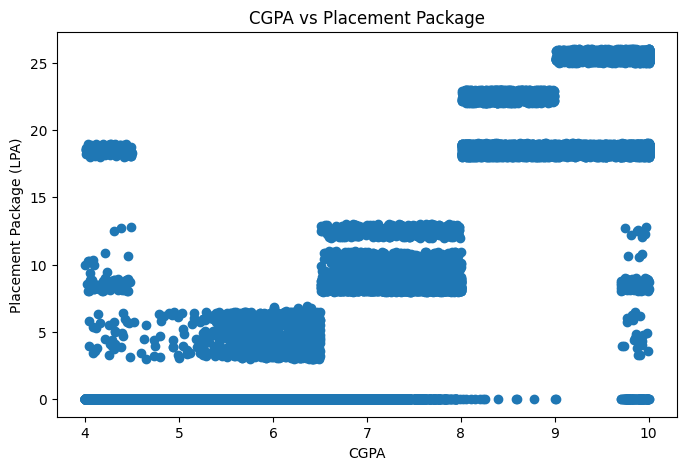

In [9]:
import matplotlib.pyplot as plt
#X = CGPA → input
#y = Package → output/target
# Visualize the relationship
plt.figure(figsize=(8, 5))


plt.scatter(X, y)


plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("CGPA vs Placement Package")


plt.show()

In [10]:
from sklearn.model_selection import train_test_split

#Students can observe that as CGPA increases, package generally increases.

# Split the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


print("Training data:")
print(X_train)


print("\nTesting data:")
print(X_test)
#Here:

#80% → Training data
#20% → Testing data

Training data:
       CGPA
5385   6.11
10810  6.10
2318   5.53
9253   7.96
13379  6.97
...     ...
5191   8.00
13418  5.45
5390   7.40
860    8.28
7270   7.26

[12355 rows x 1 columns]

Testing data:
       CGPA
150    5.60
11401  7.45
1655   4.18
9511   6.53
9758   8.61
...     ...
10794  8.36
1731   7.48
2622   6.41
4215   5.14
14884  7.51

[3089 rows x 1 columns]


In [11]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

In [17]:
# 9. Train the model

# Diagnostic: Check for NaNs before training
print('NaNs in X_train before model.fit:', X_train.isnull().sum().sum())
print('NaNs in y_train before model.fit:', y_train.isnull().sum())

# Explicitly remove NaNs from X_train and y_train to ensure clean data for the model
# Identify rows with NaNs in either X_train or y_train
combined_nan_mask = X_train.isnull().any(axis=1) | y_train.isnull()

# Filter X_train and y_train to remove rows with NaNs
X_train_cleaned = X_train[~combined_nan_mask]
y_train_cleaned = y_train[~combined_nan_mask]

# Print diagnostic after cleaning
print('NaNs in X_train after explicit cleaning:', X_train_cleaned.isnull().sum().sum())
print('NaNs in y_train after explicit cleaning:', y_train_cleaned.isnull().sum())
print('Shape of X_train after cleaning:', X_train_cleaned.shape)
print('Shape of y_train after cleaning:', y_train_cleaned.shape)

model.fit(X_train_cleaned, y_train_cleaned)

print("Model training completed.")
# Find the slope and intercept
print("Slope (β1):", model.coef_[0])
print("Intercept (β0):", model.intercept_)

NaNs in X_train before model.fit: 1
NaNs in y_train before model.fit: 1
NaNs in X_train after explicit cleaning: 0
NaNs in y_train after explicit cleaning: 0
Shape of X_train after cleaning: (12354, 1)
Shape of y_train after cleaning: (12354,)
Model training completed.
Slope (β1): 4.477653588704825
Intercept (β0): -22.856568928776873


In [18]:
# Predict the test data
y_pred = model.predict(X_test)


print("Actual values:")
print(y_test.values)


print("\nPredicted values:")
print(y_pred)
# Compare actual and predicted values
comparison = pd.DataFrame({
    'CGPA': X_test['CGPA'].values,
    'Actual Package': y_test.values,
    'Predicted Package': y_pred
})



Actual values:
[ 0.   12.85  0.   ...  0.    0.    8.62]

Predicted values:
[ 2.21829117 10.50195031 -4.13997693 ...  5.84519057  0.15857052
 10.77060952]


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#print(comparison)
#Calculate R²
r2 = r2_score(y_test, y_pred)


print("R² Score:", r2)
print("R² Percentage:", r2 * 100, "%")
# Calculate MAE and MSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

R² Score: 0.6842040979330337
R² Percentage: 68.42040979330338 %
Mean Absolute Error: 3.769087895664072
Mean Squared Error: 25.104650202598922


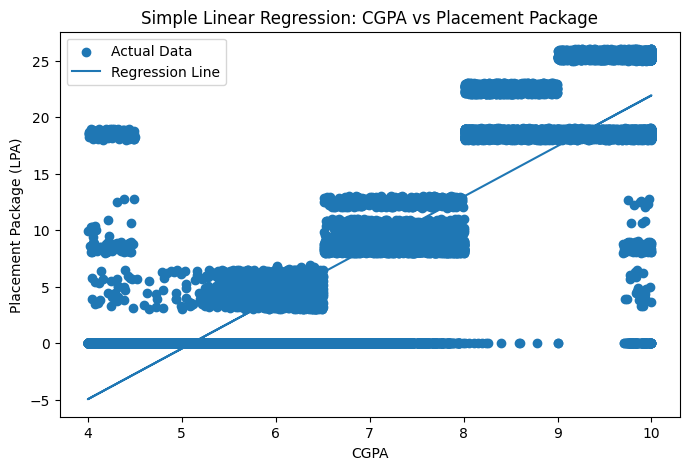

In [20]:
# Draw the regression line
plt.figure(figsize=(8, 5))


plt.scatter(X, y, label="Actual Data")


plt.plot(X, model.predict(X), label="Regression Line")


plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("Simple Linear Regression: CGPA vs Placement Package")


plt.legend()
plt.show()

#This graph shows:

#Dots → Actual student data
#Straight line → Linear Regression prediction


In [21]:
# Predict the package for a new student

#Suppose a student has 8.5 CGPA.

new_cgpa = [[8.5]]


predicted_package = model.predict(new_cgpa)


print("CGPA:", new_cgpa[0][0])
print("Predicted Placement Package:", predicted_package[0], "LPA")


CGPA: 8.5
Predicted Placement Package: 15.203486575214143 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
# Predict for multiple students
new_students = [[7.0], [8.0], [8.5], [9.0], [9.5]]


predicted_packages = model.predict(new_students)


for cgpa, package in zip(new_students, predicted_packages):
    print(f"CGPA: {cgpa[0]} -> Predicted Package: {package:.2f} LPA")

CGPA: 7.0 -> Predicted Package: 8.49 LPA
CGPA: 8.0 -> Predicted Package: 12.96 LPA
CGPA: 8.5 -> Predicted Package: 15.20 LPA
CGPA: 9.0 -> Predicted Package: 17.44 LPA
CGPA: 9.5 -> Predicted Package: 19.68 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
